# PyHEARTS introductory overview

A short end-to-end walkthrough:

1. Load the toolbox
2. Configure a **human** production run
3. Simulate ~10 s of ECG with NeuroKit2
4. Run PyHEARTS
5. Inspect beat-level features, intervals, and a simple figure

Requires: `pyhearts` installed in editable/mode (`pip install -e .`) plus `neurokit2`, `matplotlib`, `pandas`, `numpy`.

## 1. Load the toolbox

In [1]:
import pyhearts
from pyhearts import PyHEARTS

print(f"PyHEARTS {pyhearts.__version__}")
print("Core exports:", [n for n in ("PyHEARTS", "load_monitor_csv", "load_wfdb_signal") if hasattr(pyhearts, n)])


PyHEARTS 1.0.0
Core exports: ['PyHEARTS', 'load_monitor_csv', 'load_wfdb_signal']


## 2. Basic settings for a human run

`species="human"` selects the production human analyzer:

- morphology core for R/P detection, cycle segmentation, and symmetric Gaussian fitting;
- record-level T stage at the end of `analyze_ecg` for `T_global_center_idx`.

The original Gaussian T center remains available as `T_gaussian_global_center_idx`.
See `docs/PRESETS.md` for configuration.

In [9]:
SAMPLING_RATE_HZ = 500.0  # match your recording (or simulation) sample rate

analyzer = PyHEARTS(
    sampling_rate=SAMPLING_RATE_HZ,
    species="human",
)

print(f"package version: {pyhearts.__version__}")
print(f"pipeline version: {analyzer.pipeline_version}")
print(f"morphology preset: {analyzer.cfg.version}")


package version: 1.0.0
pipeline version: morphology-record-t
morphology preset: v1-human


## 3. Simulate a short ECG with NeuroKit2

~10 seconds at 70 bpm → roughly 10–12 beats, enough to see the full feature table without a long run.

samples: 5000  |  duration: 10.0 s  |  fs: 500.0 Hz


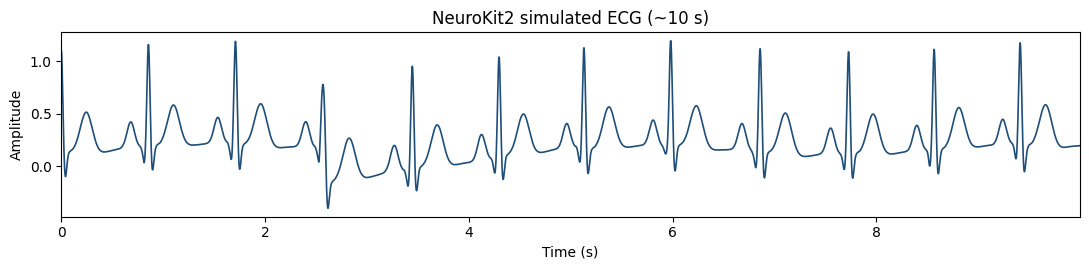

In [3]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DURATION_S = 10
HEART_RATE_BPM = 70
SEED = 42

ecg = nk.ecg_simulate(
    duration=DURATION_S,
    sampling_rate=int(SAMPLING_RATE_HZ),
    heart_rate=HEART_RATE_BPM,
    random_state=SEED,
)
ecg = np.asarray(ecg, dtype=float)
time_s = np.arange(len(ecg)) / SAMPLING_RATE_HZ

print(f"samples: {len(ecg)}  |  duration: {len(ecg) / SAMPLING_RATE_HZ:.1f} s  |  fs: {SAMPLING_RATE_HZ} Hz")

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(time_s, ecg, color="#1f4e79", lw=1.2)
ax.set_title("NeuroKit2 simulated ECG (~10 s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, time_s[-1])
fig.tight_layout()
plt.show()

## 4. Run PyHEARTS

`analyze_ecg` returns:

- **`features_df`** — one row per cardiac cycle (~136 morphological / interval columns)
- **`cycles_df`** — segmented cycle traces (`signal_x`, `signal_y`, `cycle`, …)

In [4]:
features_df, cycles_df = analyzer.analyze_ecg(ecg)

print(f"beats (cycles): {len(features_df)}")
print(f"feature columns: {features_df.shape[1]}")
print(f"cycles_df shape: {cycles_df.shape}")
print(f"mean Gaussian-fit R²: {features_df['r_squared'].mean():.3f}")

beats (cycles): 11
feature columns: 192
cycles_df shape: (4686, 4)
mean Gaussian-fit R²: 0.909


## 5. Demonstrate the output

### Interval and morphology snapshot

Core clinical-style intervals plus Gaussian wave heights from the beat model.

In [5]:
overview_cols = [
    "PR_interval_ms",
    "QRS_interval_ms",
    "QT_interval_ms",
    "RR_interval_ms",
    "P_gauss_height",
    "R_gauss_height",
    "T_gauss_height",
    "r_squared",
    "p_source",
    "t_source",
]
overview = features_df[[c for c in overview_cols if c in features_df.columns]].copy()
display(overview.round(3))

print("\nPer-column summary (finite values):")
display(overview.describe().round(2))

,PR_interval_ms,QRS_interval_ms,QT_interval_ms,RR_interval_ms,P_gauss_height,R_gauss_height,T_gauss_height,r_squared,p_source,t_source
cycle_index,,,,,,,,,,
0,112.0,140.0,386.0,NaN,0.165,0.858,0.222,0.915,per_cycle,record_t
1,114.0,140.0,390.0,854.000,0.168,0.862,0.228,0.909,per_cycle,record_t
2,112.0,146.0,408.0,859.533,0.225,0.635,0.209,0.879,per_cycle,record_t
3,118.0,138.0,388.0,876.467,0.167,0.862,0.227,0.912,per_cycle,record_t
4,110.0,138.0,386.0,851.362,0.162,0.844,0.225,0.911,per_cycle,record_t
5,114.0,134.0,384.0,832.638,0.164,0.845,0.226,0.914,per_cycle,record_t
6,104.0,148.0,400.0,852.000,0.159,0.883,0.222,0.906,per_cycle,record_t
7,116.0,142.0,394.0,877.844,0.172,0.863,0.224,0.916,per_cycle,record_t
8,116.0,140.0,384.0,868.156,0.168,0.860,0.222,0.915,per_cycle,record_t



Per-column summary (finite values):


,PR_interval_ms,QRS_interval_ms,QT_interval_ms,RR_interval_ms,P_gauss_height,R_gauss_height,T_gauss_height,r_squared
count,11.00,11.00,11.00,10.00,11.00,11.00,11.00,11.00
mean,112.55,140.36,390.73,855.57,0.17,0.84,0.21,0.91
std,3.80,3.88,7.39,15.09,0.02,0.07,0.04,0.01
min,104.00,134.00,384.00,832.64,0.16,0.64,0.09,0.88
25%,111.00,138.00,386.00,845.68,0.16,0.84,0.22,0.91
50%,112.00,140.00,388.00,853.00,0.17,0.86,0.22,0.91
75%,115.00,141.00,392.00,866.00,0.17,0.86,0.23,0.91
max,118.00,148.00,408.00,877.84,0.23,0.88,0.23,0.92


### Fiducials on the simulated trace

Global sample indices for P / R / T peaks overlaid on the input ECG.

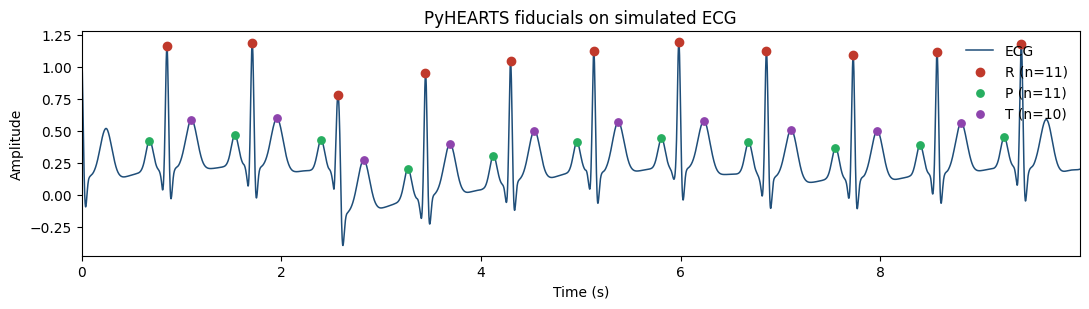

In [6]:
def _finite_idx(series):
    vals = pd.to_numeric(series, errors="coerce").dropna().to_numpy()
    return vals.astype(int)

r_idx = _finite_idx(features_df["R_global_center_idx"])
p_idx = _finite_idx(features_df["P_global_center_idx"])
t_idx = _finite_idx(features_df["T_global_center_idx"])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(time_s, ecg, color="#1f4e79", lw=1.1, label="ECG")
ax.scatter(r_idx / SAMPLING_RATE_HZ, ecg[r_idx], c="#c0392b", s=36, zorder=3, label=f"R (n={len(r_idx)})")
ax.scatter(p_idx / SAMPLING_RATE_HZ, ecg[p_idx], c="#27ae60", s=28, zorder=3, label=f"P (n={len(p_idx)})")
ax.scatter(t_idx / SAMPLING_RATE_HZ, ecg[t_idx], c="#8e44ad", s=28, zorder=3, label=f"T (n={len(t_idx)})")
ax.set_title("PyHEARTS fiducials on simulated ECG")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend(loc="upper right", frameon=False)
ax.set_xlim(0, time_s[-1])
fig.tight_layout()
plt.show()

### One segmented cycle

`cycles_df` stores each beat’s local waveform. Below: a mid-recording cycle with its detected P/R/T (global → local mapping).

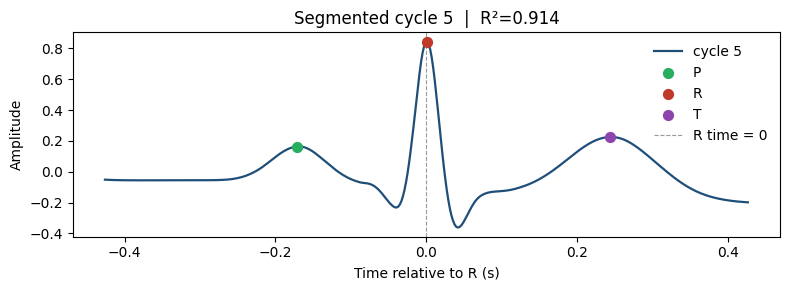

cycle 5: PR=114.0 ms, QRS=134.0 ms, QT=384.0 ms, RR=832.6 ms


In [7]:
cycle_id = int(features_df.index[len(features_df) // 2])
beat = cycles_df.loc[cycles_df["cycle"] == cycle_id].reset_index(drop=True)
row = features_df.loc[cycle_id]

# signal_x is seconds relative to the R peak; local *_center_idx index into this array
x_s = beat["signal_x"].to_numpy()
y = beat["signal_y"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x_s, y, color="#1f4e79", lw=1.6, label=f"cycle {cycle_id}")

for name, color in (("P", "#27ae60"), ("R", "#c0392b"), ("T", "#8e44ad")):
    lcol = f"{name}_center_idx"
    if lcol in features_df.columns and pd.notna(row[lcol]):
        li = int(round(float(row[lcol])))
        if 0 <= li < len(beat):
            ax.scatter([x_s[li]], [y[li]], c=color, s=50, zorder=3, label=name)

ax.axvline(0.0, color="#999999", ls="--", lw=0.8, label="R time = 0")
ax.set_title(f"Segmented cycle {cycle_id}  |  R²={row['r_squared']:.3f}")
ax.set_xlabel("Time relative to R (s)")
ax.set_ylabel("Amplitude")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
plt.show()

print(
    f"cycle {cycle_id}: PR={row.get('PR_interval_ms', float('nan')):.1f} ms, "
    f"QRS={row.get('QRS_interval_ms', float('nan')):.1f} ms, "
    f"QT={row.get('QT_interval_ms', float('nan')):.1f} ms, "
    f"RR={row.get('RR_interval_ms', float('nan')):.1f} ms"
)

### Beat-to-beat variability

Beat-level output is a regular pandas DataFrame, so variability summaries can be computed directly with `std`, `median`, `quantile`, or grouped analyses.

> **Note:** formal HRV (`analyzer.compute_hrv_metrics()`) expects ≥60 valid RR intervals,
> so it is intentionally skipped on a ~10 s clip. Use a longer recording for SDNN/RMSSD.

In [8]:
highlight = [
    "RR_interval_ms",
    "PR_interval_ms",
    "QT_interval_ms",
    "QRS_interval_ms",
    "R_gauss_height",
    "T_gauss_height",
]

available = [column for column in highlight if column in features_df]
variability = features_df[available].agg(["count", "mean", "std", "median"]).T
variability["cv"] = variability["std"] / variability["mean"].abs()
display(variability.round(3))

,metric,value
0,RR_interval_ms_std,15.095
1,PR_interval_ms_std,3.804
2,QT_interval_ms_std,7.390
3,QRS_interval_ms_std,3.880
4,R_gauss_height_std,0.068
5,T_gauss_height_std,0.040



Total variability metrics stored: 65


## 6. Minimal recipe (copy-paste)

```python
import neurokit2 as nk
from pyhearts import PyHEARTS

fs = 500.0
ecg = nk.ecg_simulate(duration=10, sampling_rate=int(fs), heart_rate=70, random_state=42)

analyzer = PyHEARTS(sampling_rate=fs, species="human")
features_df, cycles_df = analyzer.analyze_ecg(ecg)

features_df[[
    "P_global_center_idx",
    "R_global_center_idx",
    "T_global_center_idx",
    "T_gaussian_global_center_idx",
    "r_squared",
]].head()
```

For real monitor CSV exports, see the quickstart in `README.md` (`load_monitor_csv`).
Preset details: `docs/PRESETS.md`.